# Load Data

In [63]:
import sys
from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\maxan\OneDrive\Desktop\0. Personal Projects\market-intelligence-pipeline")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [64]:
import pandas as pd
import numpy as np
import duckdb

from src.config import (
    DATABASE_PATH,
    ROLLING_WINDOWS,
    LAGGED_WINDOWS,
    MA_WINDOWS,
    TICKERS,
    START_DATE,
    END_DATE
)

from src.features import (
    build_price_feature_columns
)

CALENDAR = "no_calendar"


def pull_calendar_table(table_name: str, calendar: str) -> pd.DataFrame:

    print("[START] Connecting to database...")

    con = duckdb.connect(DATABASE_PATH)

    print(f"[START] Reading {table_name}")

    df = con.sql(f"""
    
        SELECT *
        FROM {table_name}

    """).df()

    print(f"[DONE] Read {table_name}")

    con.close()

    print(f"[START] Building {CALENDAR} required columns...")

    base_cols = [
        "ticker",
        "date",
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume"
    ]

    feature_columns = build_price_feature_columns(
        calendars = [CALENDAR],
        rolling_windows = ROLLING_WINDOWS,
        lagged_windows = LAGGED_WINDOWS,
        ma_windows = MA_WINDOWS
    )

    expected_columns = base_cols + list(feature_columns.keys())

    calendar_df = df[expected_columns].copy()

    print(f"[DONE] Filtered to {CALENDAR}")

    calendar_df["date"] = pd.to_datetime(calendar_df["date"])

    calendar_df = calendar_df.sort_values(["ticker", "date"])

    print(f"[DONE] Prepared and sorted table")

    return calendar_df

In [65]:
df = pull_calendar_table(
    table_name = "price_features", 
    calendar = CALENDAR
    )

print(f"[STEP] Loaded price_features table selecting {CALENDAR} columns")
print(df.head(10))
print(df.columns)

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar
[DONE] Prepared and sorted table
[STEP] Loaded price_features table selecting no_calendar columns
      ticker       date        open        high         low       close  \
0        GLD 2018-01-02  124.660004  125.180000  124.389999  125.150002   
1        GLD 2018-01-03  125.050003  125.089996  124.099998  124.820000   
8585     GLD 2018-01-04  124.889999  125.849998  124.739998  125.459999   
4299     GLD 2018-01-05  124.930000  125.480003  124.830002  125.330002   
2        GLD 2018-01-08  125.199997  125.320000  124.900002  125.309998   
7160     GLD 2018-01-09  124.489998  124.860001  124.230003  124.730003   
4300     GLD 2018-01-10  125.169998  125.309998  124.720001  125.029999   
10109    GLD 2018-01-11  125.370003  125.660004  125.250000  125.440002   
10110    GLD 2018-01-12  126.010002  127.129997  125.80

In [66]:
table_count = 0
graph_count = 0

# Plotting Daily Returns

Graph 1:


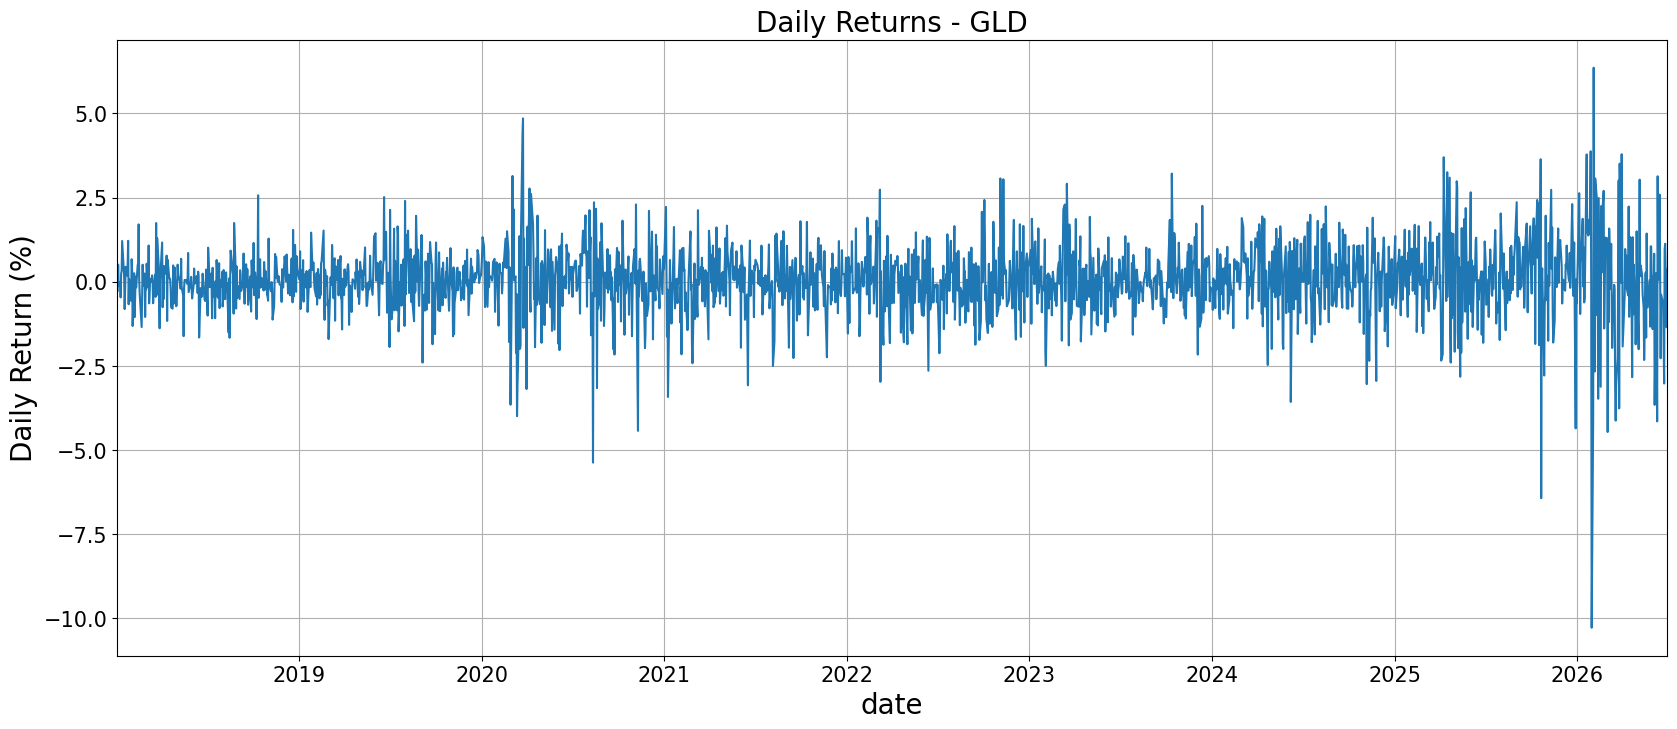

Graph 2:


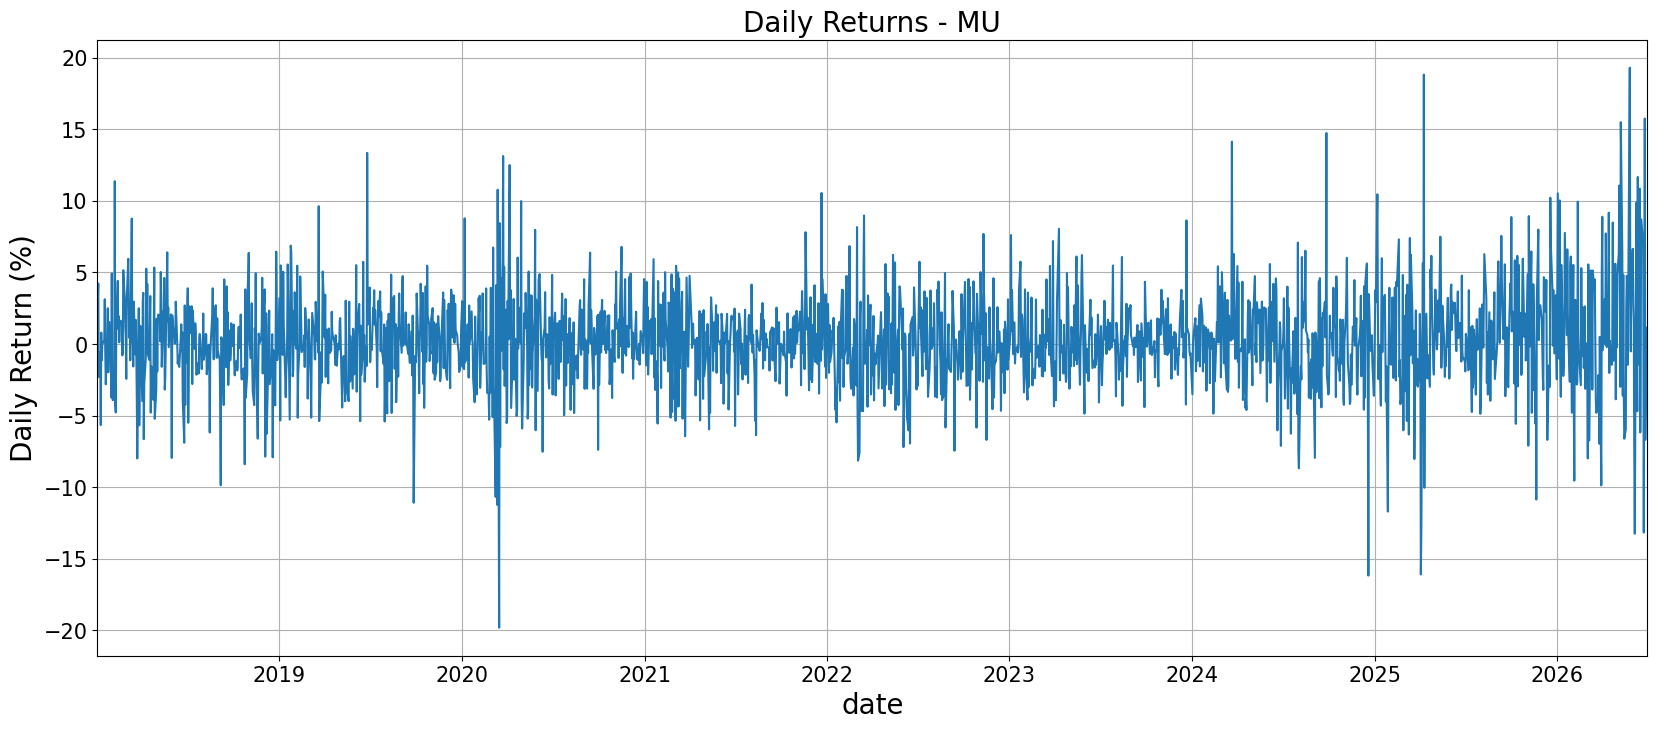

Graph 3:


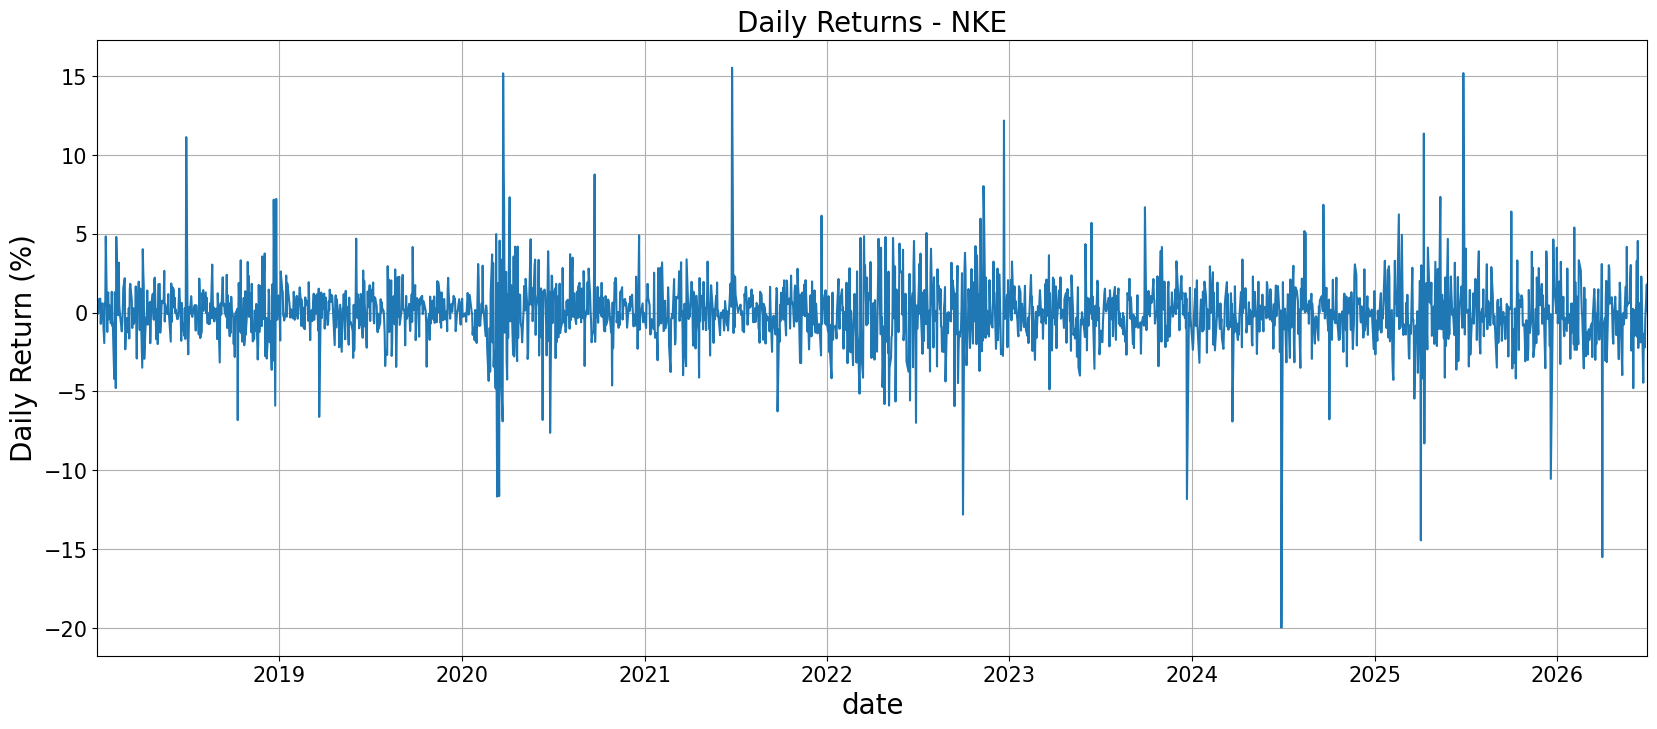

Graph 4:


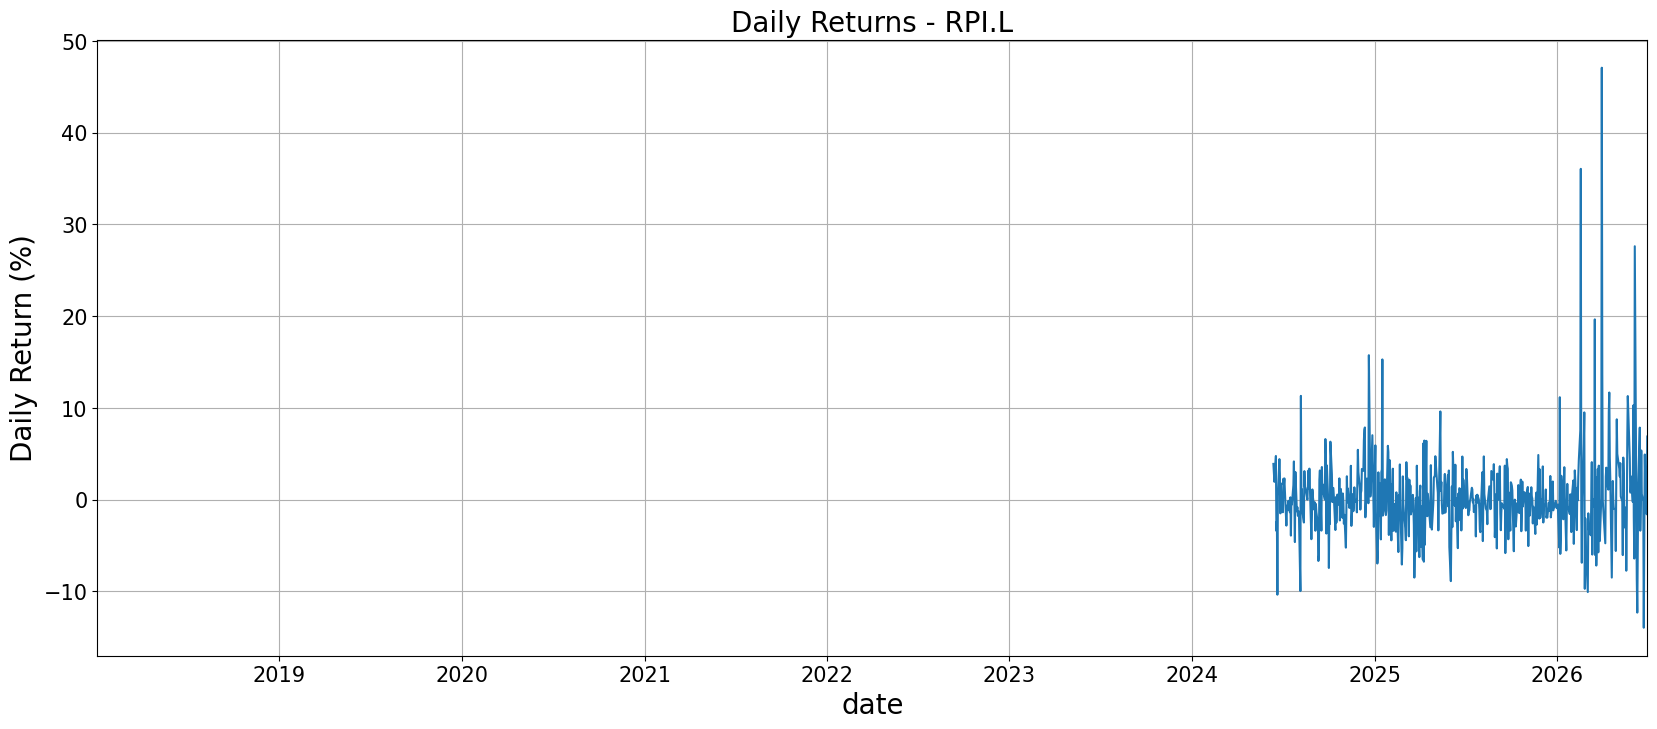

Graph 5:


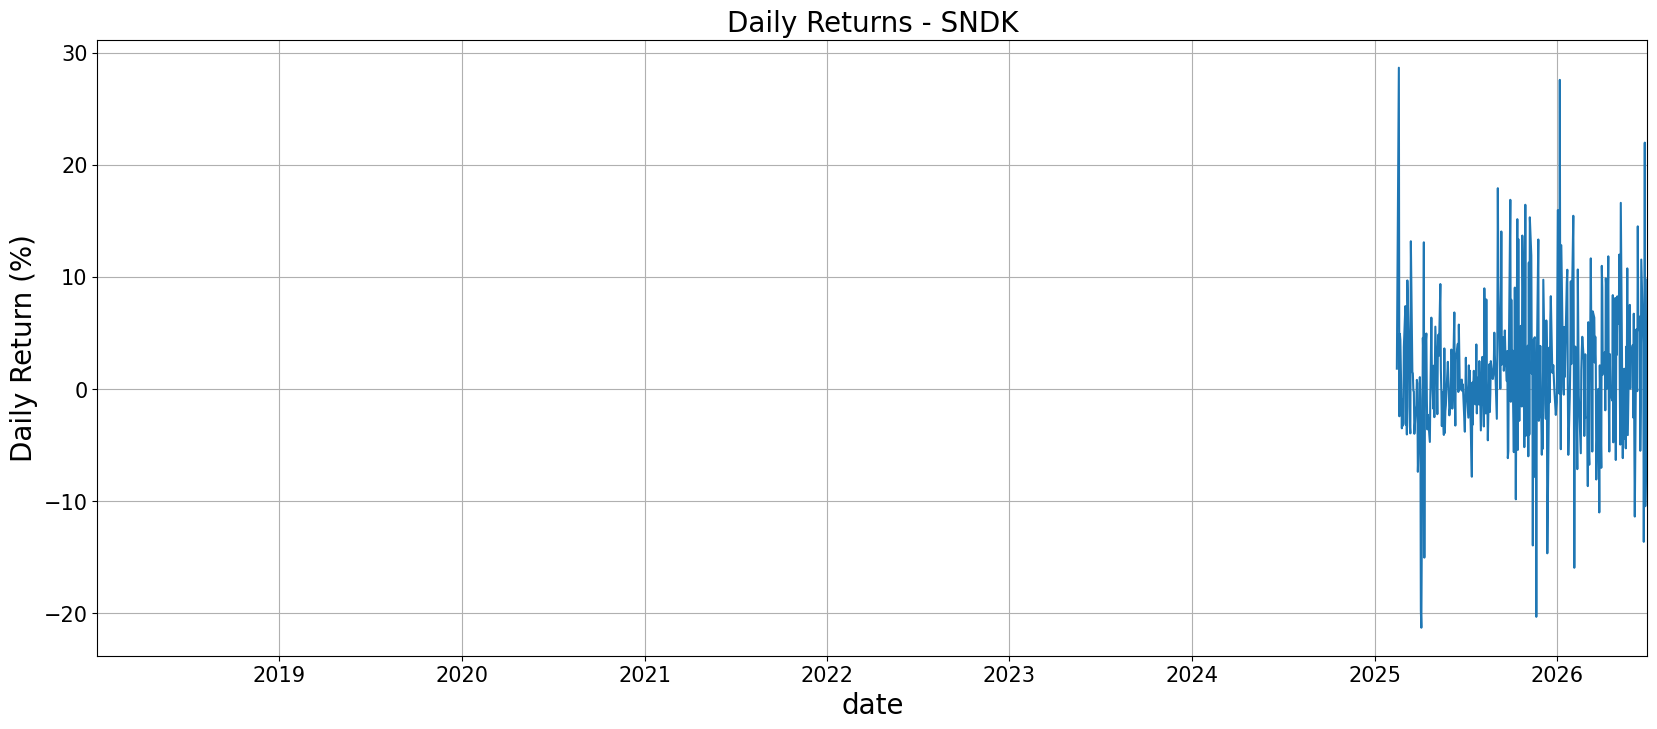

Graph 6:


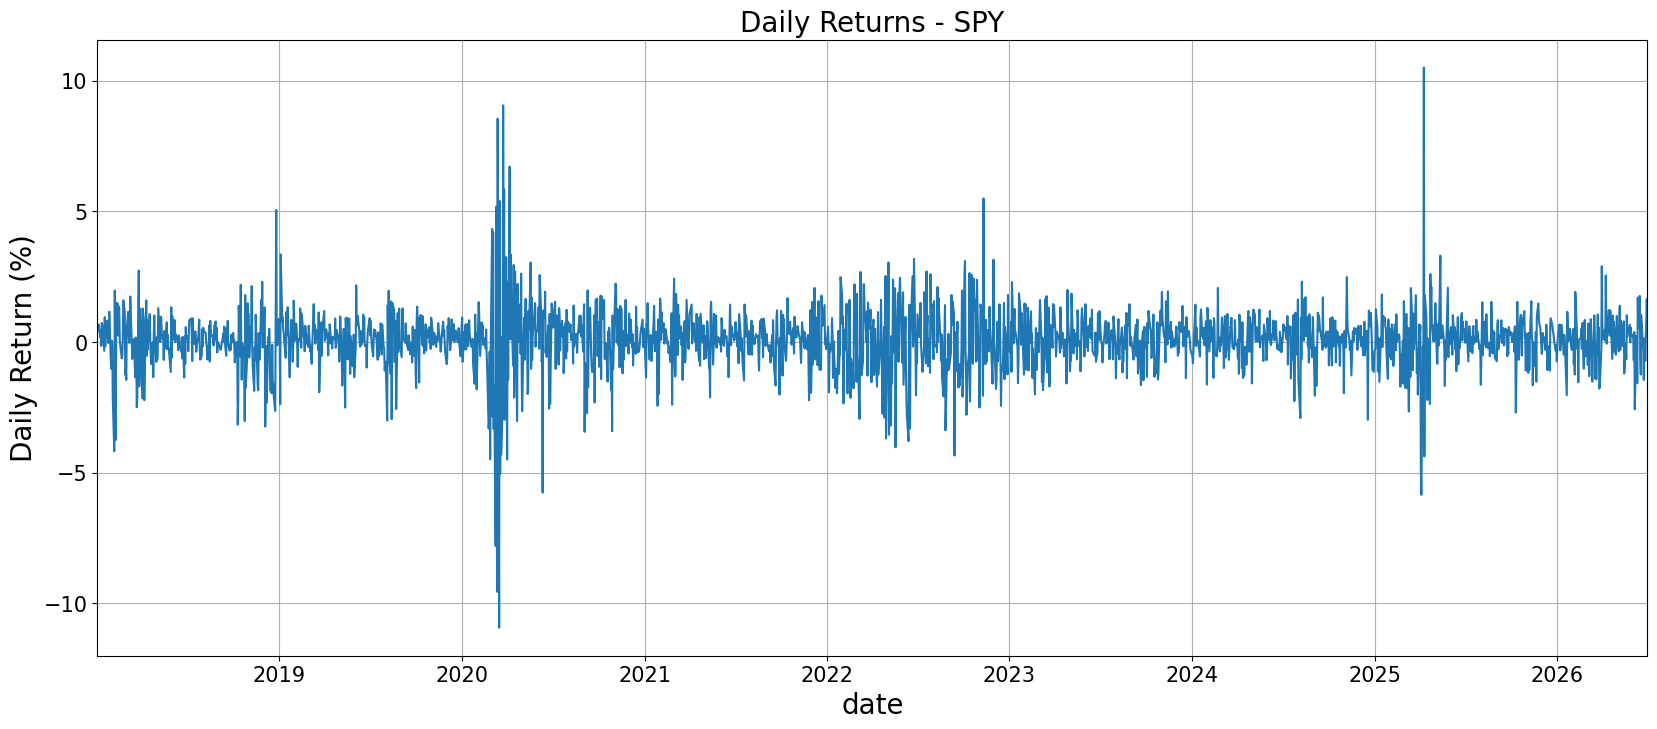

Graph 7:


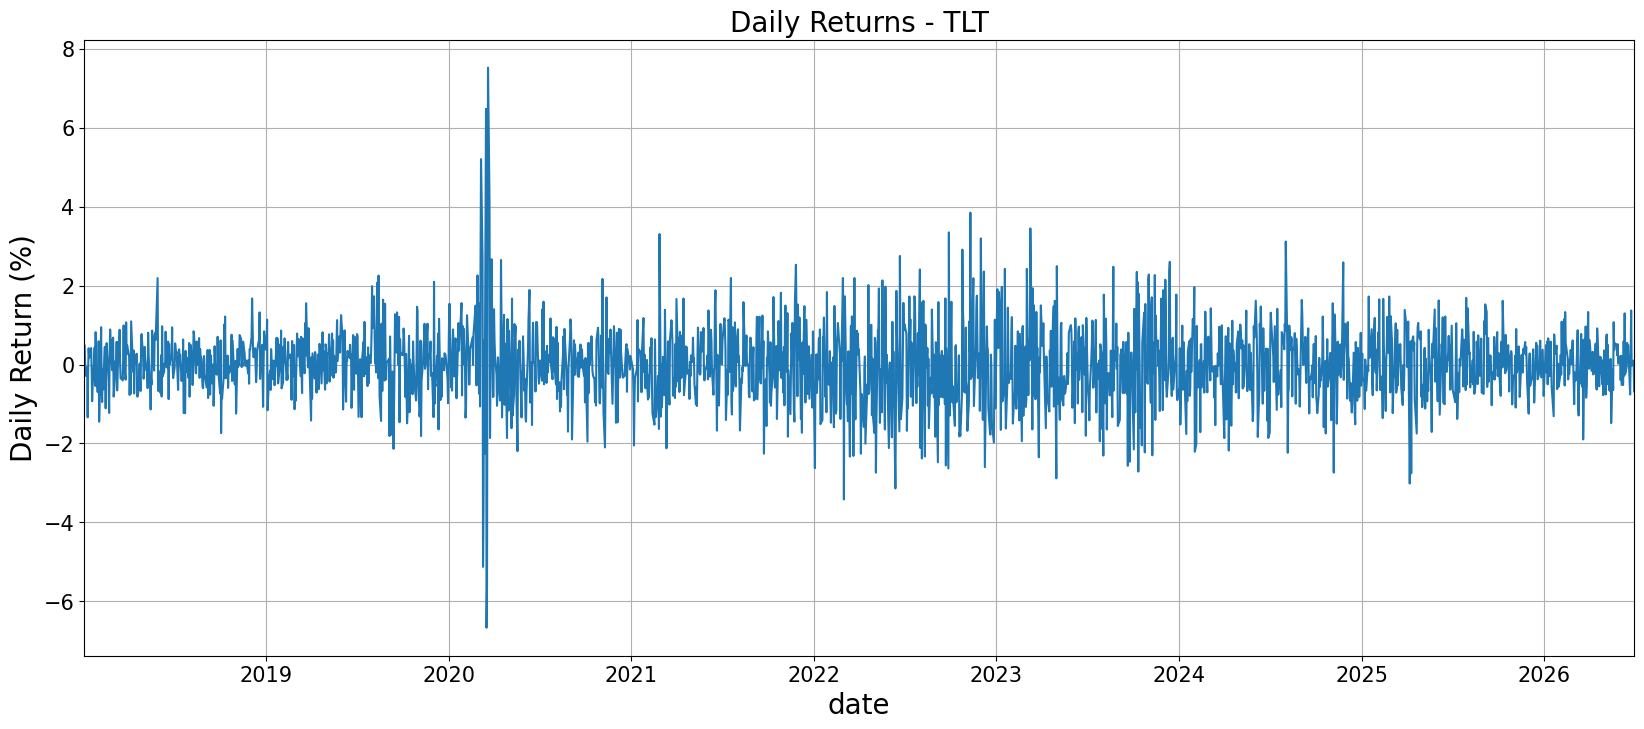

In [67]:
import matplotlib.pyplot as plt

df_1 = df.copy()

daily_return = f"daily_return_{CALENDAR}"
ticker = "ticker"
date = "date"

df_1[daily_return] = df_1[daily_return] * 100

x_min = df_1[date].min()
x_max = df_1[date].max()

for asset, group in df_1.groupby(ticker):
    plt.figure(figsize=(20,8))
    plt.plot(group[date], group[daily_return], label = asset)
    plt.title(f"Daily Returns - {asset}", fontsize = 20)
    plt.xlabel(date, fontsize = 20)
    plt.ylabel("Daily Return (%)", fontsize = 20)
    plt.xticks(fontsize = 15)
    plt.yticks(fontsize = 15)
    plt.xlim(x_min, x_max)
    plt.grid()
    graph_count += 1
    print(f"Graph {graph_count}:")
    plt.show()



# Plotting Return Distributions

Graph 8:


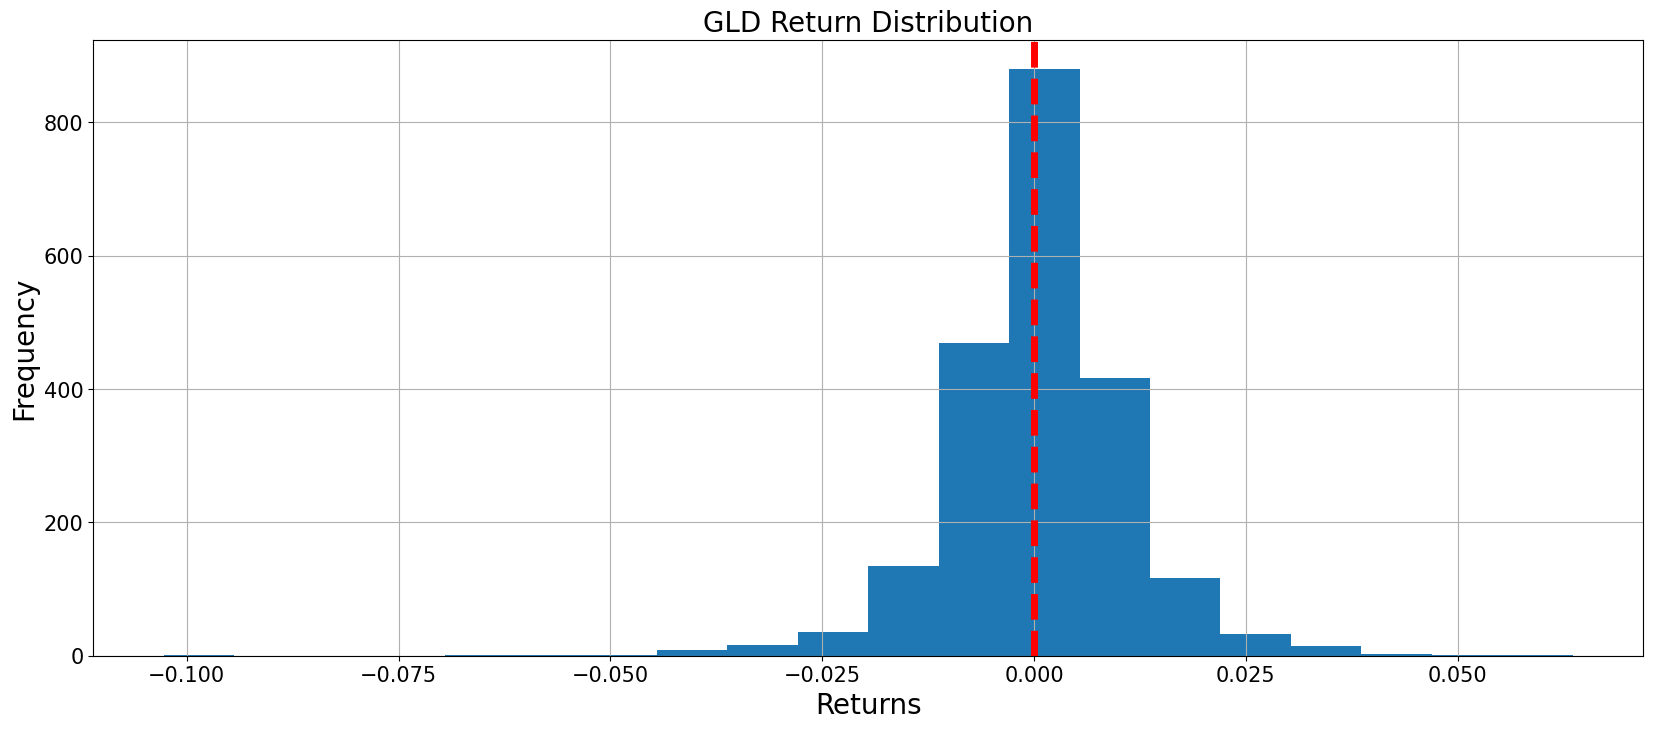

Graph 9:


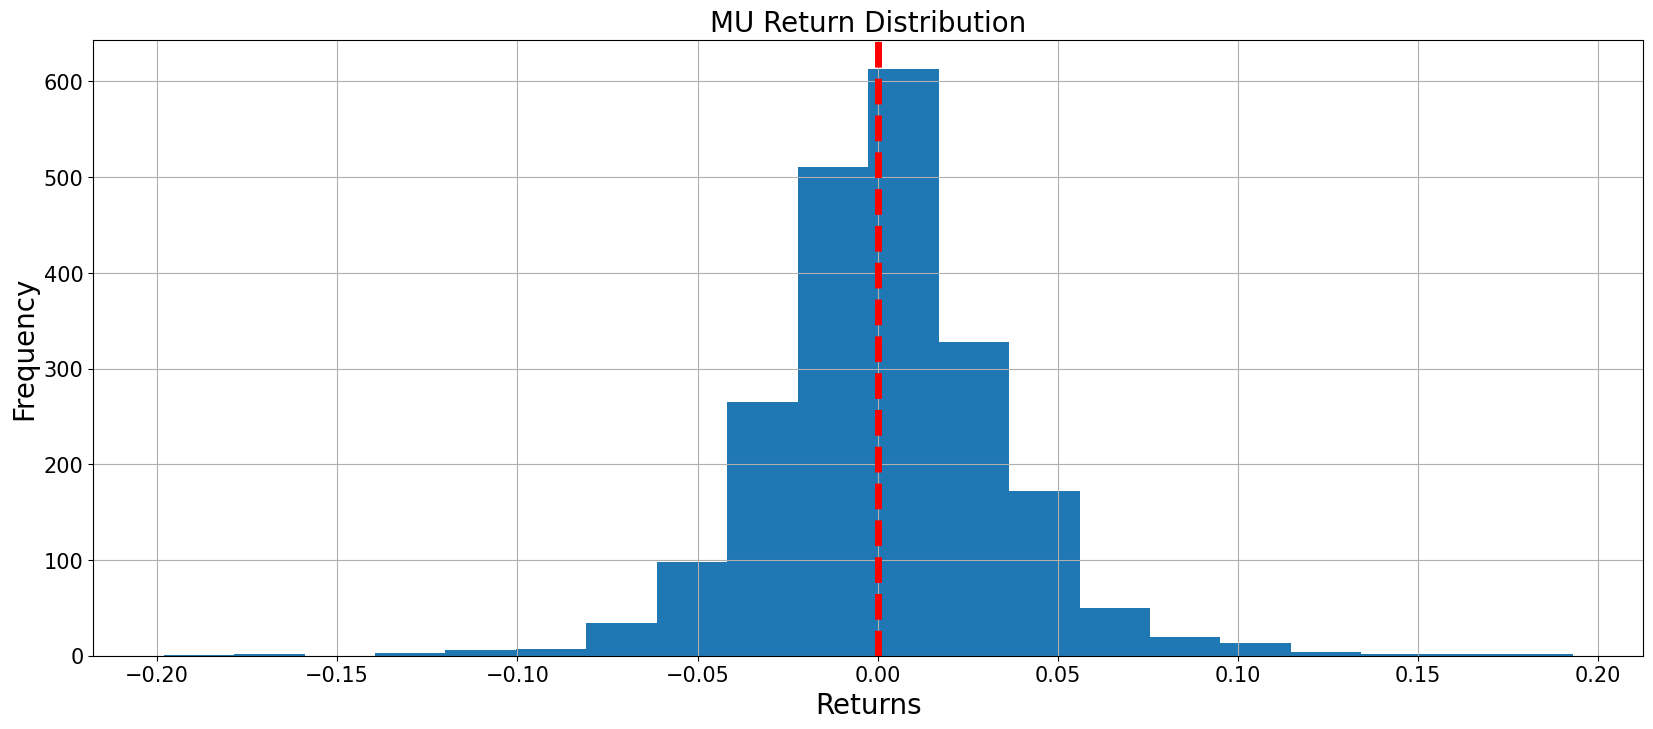

Graph 10:


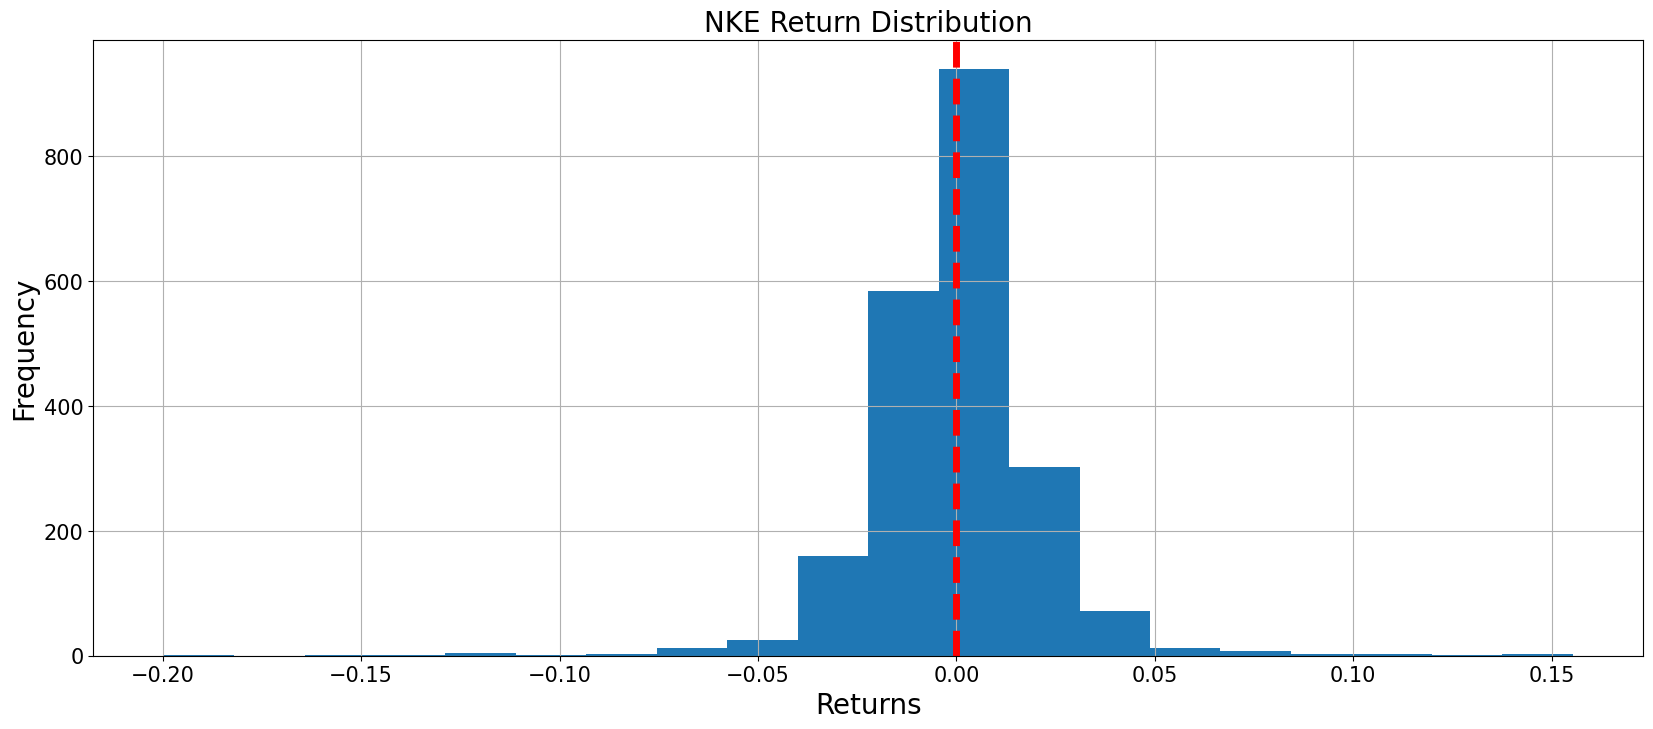

Graph 11:


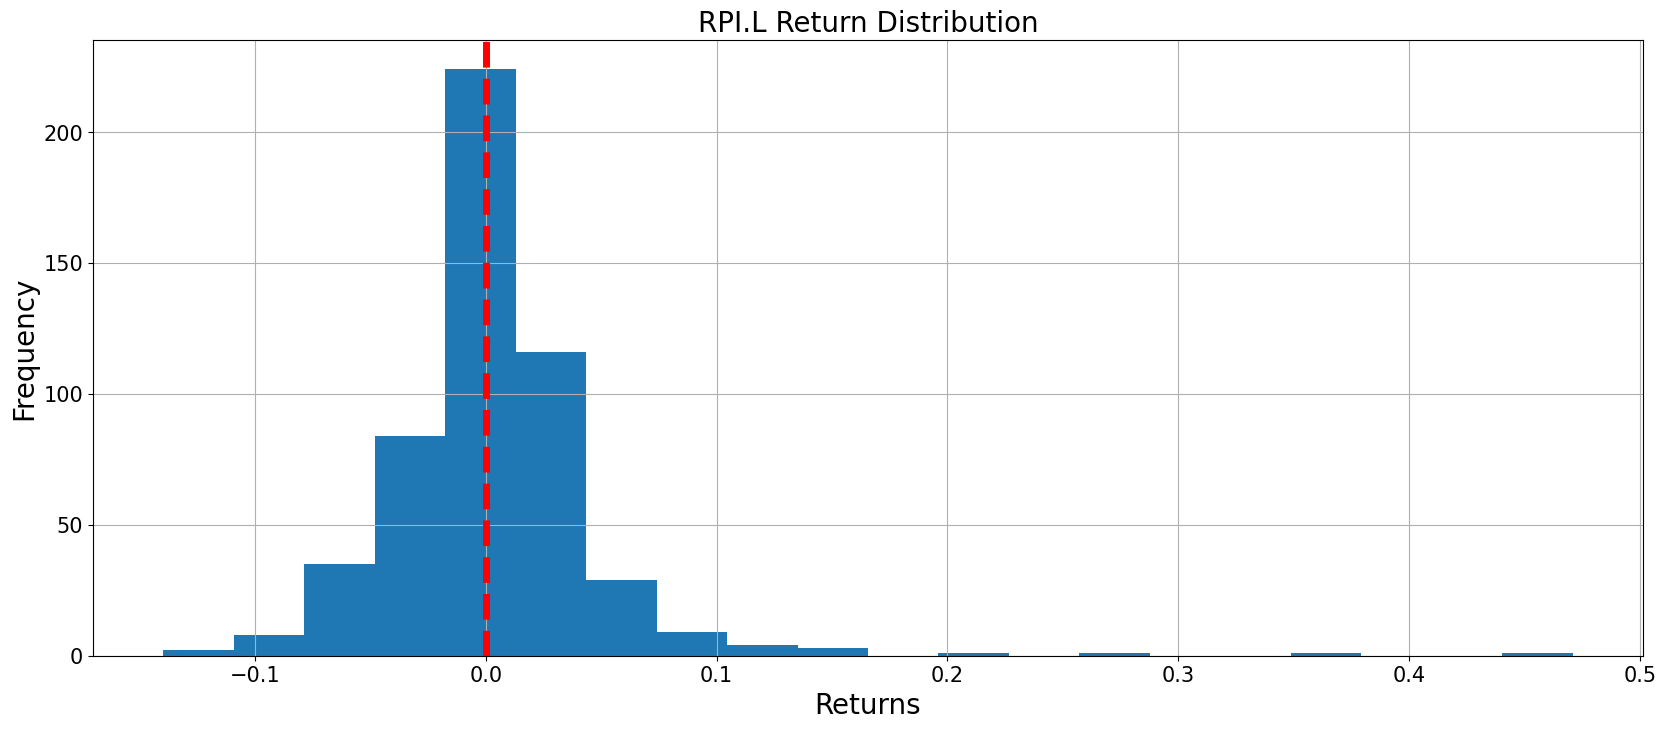

Graph 12:


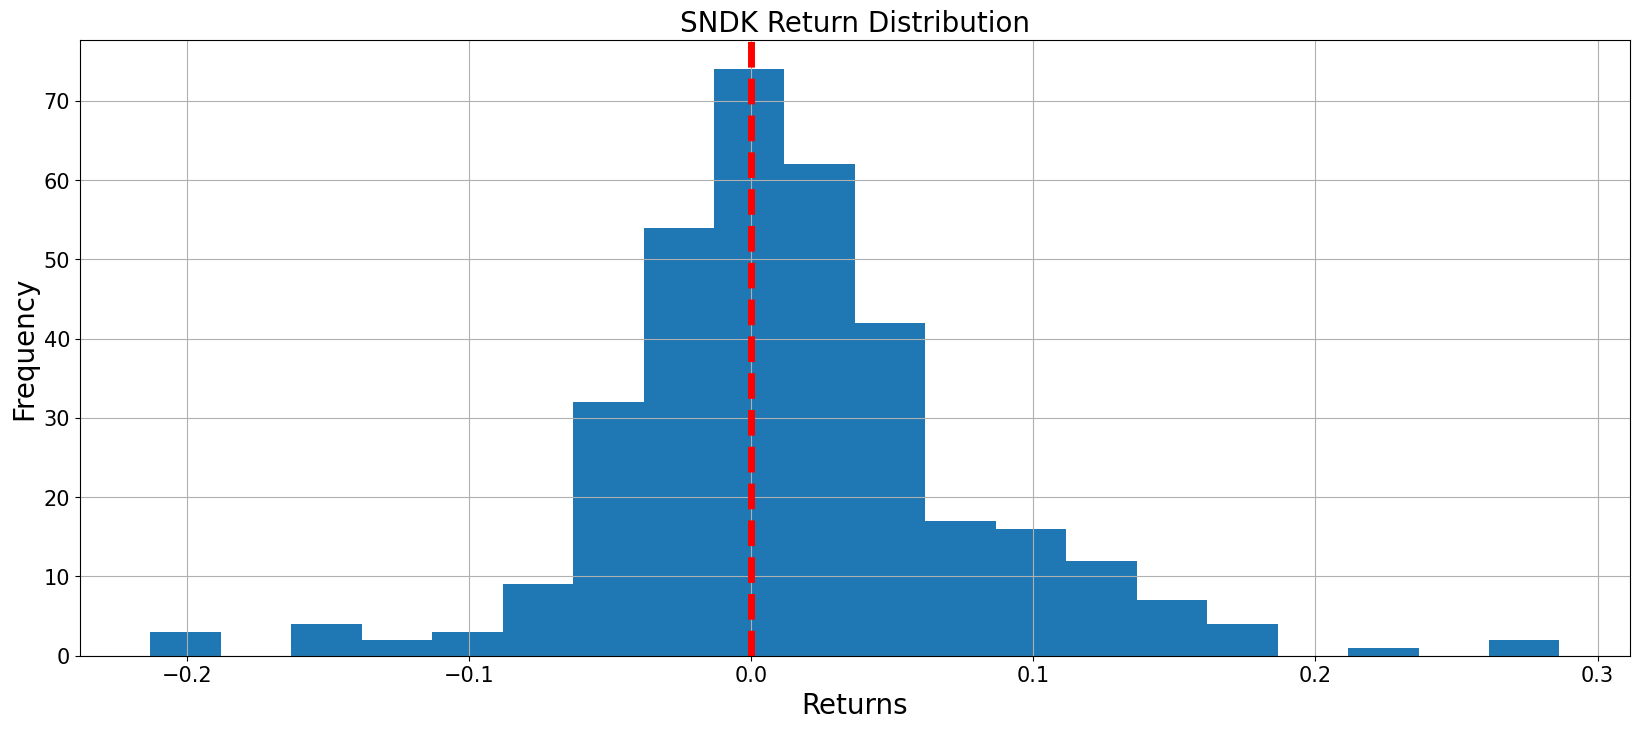

Graph 13:


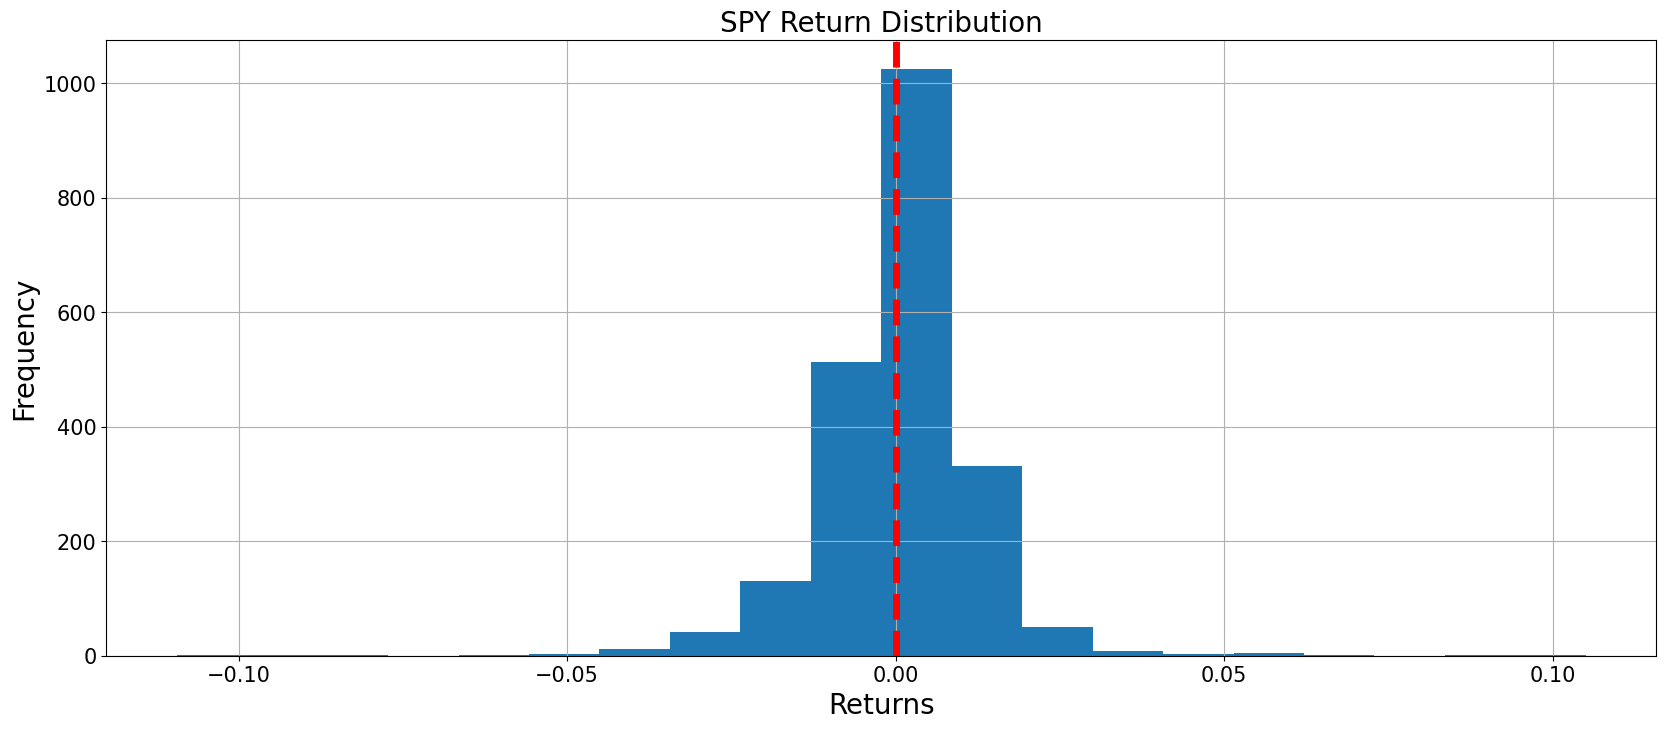

Graph 14:


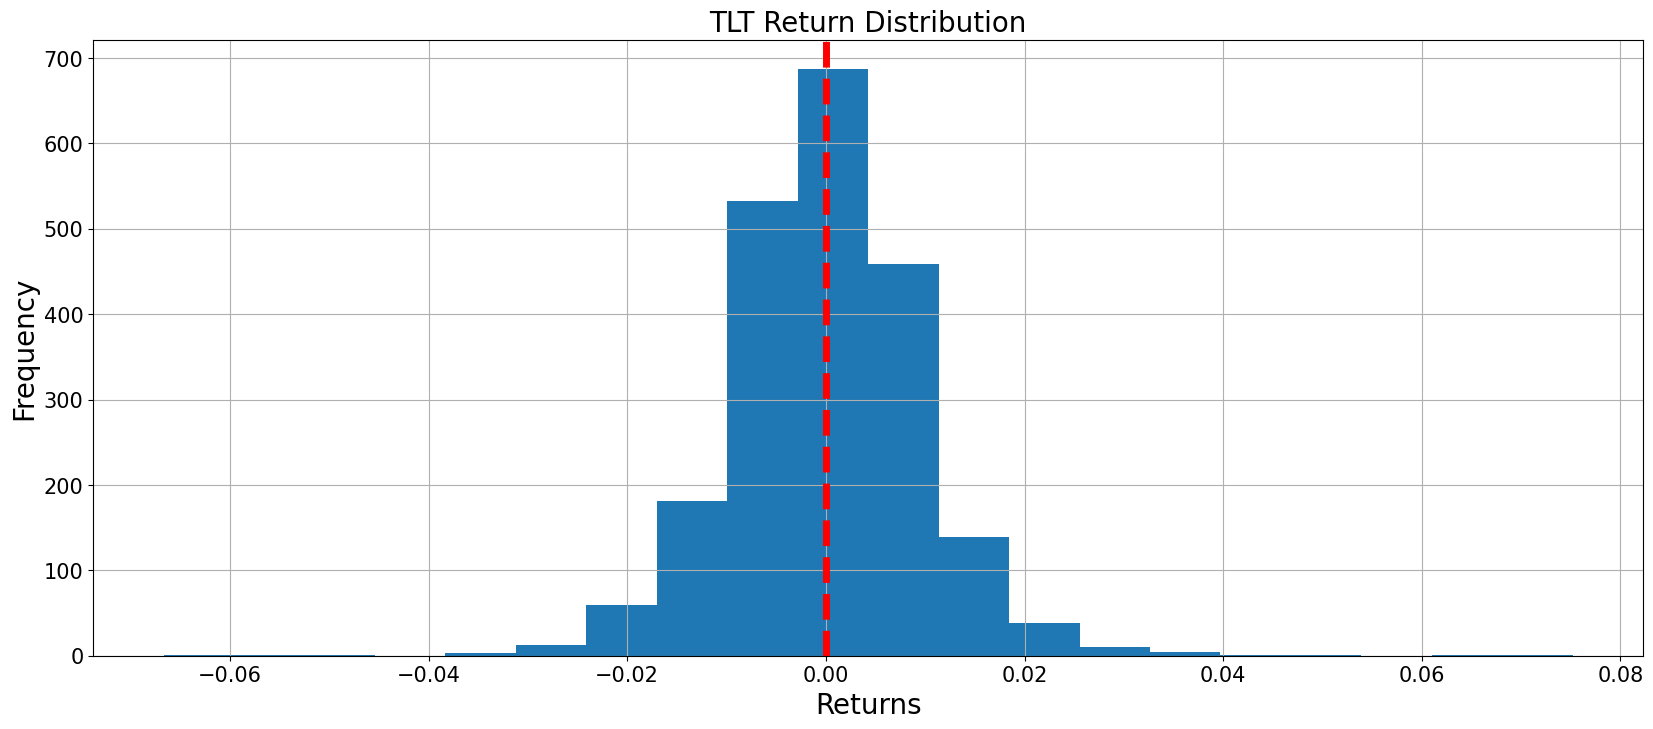

In [68]:
df_2 = df.copy()

for asset, group in df_2.groupby(ticker):
    returns = group[daily_return]
    plt.figure(figsize=(20,8))
    plt.hist(returns.dropna(), bins=20)
    plt.title(f"{asset} Return Distribution", fontsize = 20)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.xlabel("Returns", fontsize = 20)
    plt.ylabel("Frequency", fontsize = 20)
    plt.axvline(0, linestyle = "--", color = "red", linewidth = "5")
    plt.grid()
    graph_count += 1
    print(f"Graph {graph_count}:")

    plt.show()

# Comparing Average Returns, Volatility and Extreme Return Days

In [73]:
df_3 = df.copy()

summary = (
    df_3.groupby(ticker)[daily_return]
        .agg(
            avg_daily_return = "mean",
            volatility =  "std",
            largest_gain = "max",
            largest_loss = "min",
            observations = "count"
        )
)

summary_pct = summary.copy()

summary_pct["avg_daily_return"] = summary_pct["avg_daily_return"] * 100
summary_pct["volatility"] = summary_pct["volatility"] * 100
summary_pct["largest_gain"] = summary_pct["largest_gain"] * 100
summary_pct["largest_loss"] = summary_pct["largest_loss"] * 100
summary_pct["return_to_risk"] = (summary_pct["avg_daily_return"]/ summary_pct["volatility"])*100

summary_pct = summary_pct.sort_values("avg_daily_return", ascending=False)

table_count += 1
print(f"Table {table_count}:")

display(
    summary_pct.reset_index().style.hide(axis="index").format({
        "avg_daily_return": "{:.2f}%",
        "volatility": "{:.2f}%",
        "largest_gain": "{:.2f}%",
        "largest_loss": "{:.2f}%",
        "return_to_risk": "{:.2f}%",
        "observations": "{:.0f}"
    })
)

Table 7:


ticker,avg_daily_return,volatility,largest_gain,largest_loss,observations,return_to_risk
SNDK,1.41%,6.43%,28.65%,-21.30%,344,21.95%
RPI.L,0.25%,4.74%,47.09%,-13.96%,518,5.27%
MU,0.21%,3.31%,19.29%,-19.82%,2133,6.32%
SPY,0.06%,1.21%,10.50%,-10.94%,2133,5.08%
GLD,0.06%,1.06%,6.36%,-10.27%,2133,5.33%
NKE,0.01%,2.14%,15.53%,-19.98%,2133,0.40%
TLT,-0.00%,0.97%,7.52%,-6.67%,2133,-0.13%


Graph 15:


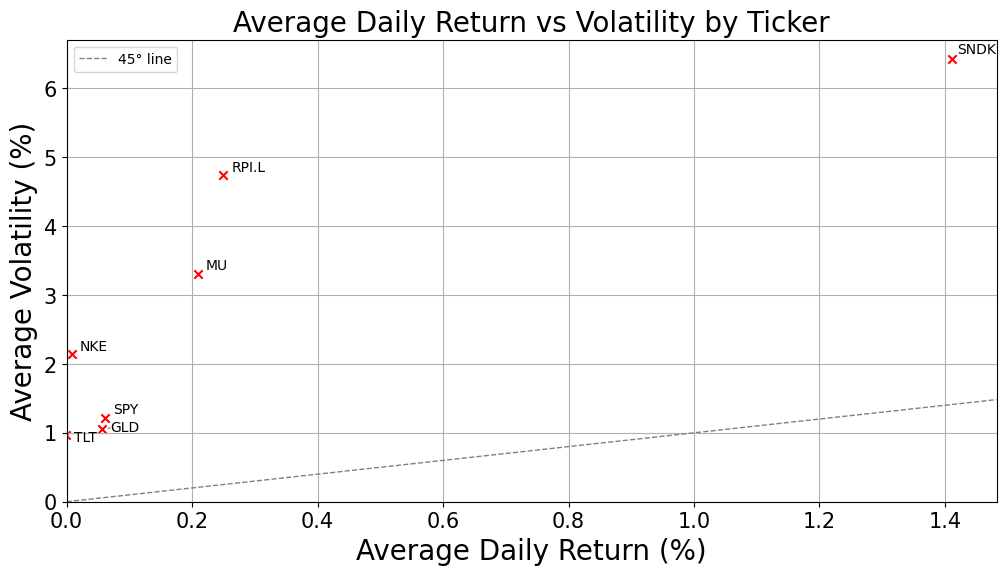

In [70]:
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.ticker import FormatStrFormatter

plt.figure(figsize=(12,6))

plt.scatter(
    summary_pct["avg_daily_return"],
    summary_pct["volatility"],
    marker = "x",
    color = "red"
    
)

texts = []
for asset in summary_pct.index:
    texts.append(
        plt.text(
            0.01 + summary_pct.loc[asset, "avg_daily_return"],
            0.01 + summary_pct.loc[asset, "volatility"],
            asset
        )
    )

adjust_text(
    texts,
    x=summary_pct["avg_daily_return"],
    y=summary_pct["volatility"],
    arrowprops=dict(arrowstyle="-", lw=0.5)
)


plt.ylabel("Average Volatility (%)", fontsize=20)
plt.xlabel("Average Daily Return (%)", fontsize=20)
plt.yticks(fontsize = 15)
plt.xticks(fontsize = 15)
plt.title("Average Daily Return vs Volatility by Ticker", fontsize=20)

plt.xlim(left=0)
plt.ylim(bottom=0)

xlim = plt.xlim()
ylim = plt.ylim()

line_end = min(xlim[1], ylim[1])

plt.plot(
    [0, line_end],
    [0, line_end],
    linestyle="--",
    linewidth=1,
    color="gray",
    label="45° line"
)

plt.legend()

plt.grid()

graph_count += 1
print(f"Graph {graph_count}:")

plt.show()

In [77]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, HTML

df_4 = df.copy()

date = "date"
ticker = "ticker"
log_return = f"log_return_{CALENDAR}"
daily_return = f"daily_return_{CALENDAR}"

idx_daily_gain = (
    df_4.groupby(ticker)[daily_return]
        .nlargest(5)
        .index.get_level_values(1)
)

daily_gain = (
    df_4.loc[idx_daily_gain, [ticker, date, daily_return]]
        .rename(columns={
            date: "max_daily_gain_date",
            daily_return: "max_daily_gain"
        })
        .set_index(ticker)
)

idx_daily_loss = (
    df_4.groupby(ticker)[daily_return]
        .nsmallest(5)
        .index.get_level_values(1)
)

daily_loss = (
    df_4.loc[idx_daily_loss, [ticker, date, daily_return]]
        .rename(columns={
            date: "max_daily_loss_date",
            daily_return: "max_daily_loss"
        })
        .set_index(ticker)
)

weekly_returns = (
    df_4.set_index(date)
        .groupby(ticker)[log_return]
        .resample("W")
        .sum()
        .rename("weekly_log_return")
        .reset_index()
)

weekly_returns["weekly_return"] = np.exp(weekly_returns["weekly_log_return"]) - 1

idx_weekly_gain = (
    weekly_returns.groupby(ticker)["weekly_return"]
        .nlargest(5)
        .index.get_level_values(1)
)


weekly_gain = (
    weekly_returns.loc[idx_weekly_gain, [ticker, date, "weekly_return"]]
        .rename(columns={
            date: "max_weekly_gain_week_ending",
            "weekly_return": "max_weekly_gain"
        })
        .set_index(ticker)
)

idx_weekly_loss = (
    weekly_returns.groupby(ticker)["weekly_return"]
        .nsmallest(5)
        .index.get_level_values(1)
)

weekly_loss = (
    weekly_returns.loc[idx_weekly_loss, [ticker, date, "weekly_return"]]
        .rename(columns={
            date: "max_weekly_loss_week_ending",
            "weekly_return": "max_weekly_loss"
        })
        .set_index(ticker)
)

def add_rank(table, value_col, ascending):
    table = table.reset_index()

    return (
        table.sort_values([ticker, value_col], ascending=[True, ascending])
             .assign(rank=lambda x: x.groupby(ticker).cumcount() + 1)
             .set_index([ticker, "rank"])
    )

daily_gain = add_rank(daily_gain, "max_daily_gain", ascending=False)
daily_loss = add_rank(daily_loss, "max_daily_loss", ascending=True)
weekly_gain = add_rank(weekly_gain, "max_weekly_gain", ascending=False)
weekly_loss = add_rank(weekly_loss, "max_weekly_loss", ascending=True)

summary = (
    daily_gain
        .join(daily_loss)
        .join(weekly_gain)
        .join(weekly_loss)
)

summary = summary[
    [
        "max_daily_gain_date",
        "max_daily_gain",
        "max_daily_loss_date",
        "max_daily_loss",
        "max_weekly_gain_week_ending",
        "max_weekly_gain",
        "max_weekly_loss_week_ending",
        "max_weekly_loss"
    ]
]

tables = {
    "max_daily_gain": summary[["max_daily_gain_date", "max_daily_gain"]]
        .sort_values("max_daily_gain_date", ascending=False),

    "max_daily_loss": summary[["max_daily_loss_date", "max_daily_loss"]]
        .sort_values("max_daily_loss_date", ascending=True),

    "max_weekly_gain": summary[["max_weekly_gain_week_ending", "max_weekly_gain"]]
        .sort_values("max_weekly_gain_week_ending", ascending=False),

    "max_weekly_loss": summary[["max_weekly_loss_week_ending", "max_weekly_loss"]]
        .sort_values("max_weekly_loss_week_ending", ascending=True)
}

html_parts = []

for name, table in tables.items():
    table = table.reset_index()

    styled_table = (
        table.style
             .hide(axis="index")
             .format({
                 "max_daily_gain": "{:.2%}",
                 "max_daily_loss": "{:.2%}",
                 "max_weekly_gain": "{:.2%}",
                 "max_weekly_loss": "{:.2%}"
             }, na_rep="")
    )

    table_count += 1

    html_parts.append(f"""
    <div>
        <h3>Table {table_count}: {name}</h3>
        {styled_table.to_html()}
    </div>
    """)

    

html = f"""
<div style="display: flex; gap: 30px; align-items: flex-start;">
    {''.join(html_parts)}
</div>
"""

display(HTML(html))

ticker,rank,max_daily_gain_date,max_daily_gain
SNDK,3,2026-06-25 00:00:00,21.97%
MU,3,2026-06-25 00:00:00,15.74%
RPI.L,3,2026-06-05 00:00:00,27.63%
MU,1,2026-05-26 00:00:00,19.29%
MU,4,2026-05-08 00:00:00,15.49%
RPI.L,1,2026-03-31 00:00:00,47.09%
GLD,5,2026-03-31 00:00:00,3.79%
RPI.L,4,2026-03-17 00:00:00,19.66%
RPI.L,2,2026-02-17 00:00:00,36.07%
GLD,1,2026-02-03 00:00:00,6.36%


# Inspecting Skewness and Kurtosis

In [72]:
df_5 = df.copy()

distribution_summary = (
    df_5.groupby(ticker)[daily_return]
      .agg(
          mean_return="mean",
          volatility="std",
          skewness="skew",
          kurtosis="kurt",
          observations="count"
      )
)

table_count += 1
print(f"Table {table_count}:")

display(distribution_summary.reset_index().style.hide(axis="index"))



Table 6:


ticker,mean_return,volatility,skewness,kurtosis,observations
GLD,0.000564,0.010588,-0.636367,7.305299,2133
MU,0.002091,0.033101,0.175578,3.593143,2133
NKE,0.000087,0.021387,-0.268748,12.821108,2133
RPI.L,0.002499,0.047394,3.267675,26.666113,518
SNDK,0.014118,0.064327,0.345475,2.506943,344
SPY,0.000614,0.012091,-0.294439,13.116533,2133
TLT,-0.000013,0.009738,0.161246,5.043367,2133
